In [98]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Добавим некоторые данные из pretrain набора

Загрузим полный набор данных

In [102]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [103]:
train_part1.schema

C:\Users\User\AppData\Local\Temp\ipykernel_3928\896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('customer_id', Int64),
        ('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [104]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 22)

In [105]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 22)

In [106]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

In [107]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 22)

In [108]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [109]:
x = train_part1.drop("target")
y = train_part1["target"]

In [110]:
# X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)   
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [ ]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null(-1))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null(-1))

In [ ]:
X_train = X_train.drop("customer_id")
X_test = X_test.drop("customer_id")

In [114]:
X_train

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour
i16,i16,i16,i16,f64,i16,i16,i16,i16,f64,i16,str,str,str,i16,i16,i16,i16,i16
7,56,4,15,null,-1,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
14,101,4,15,3005.0,0,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
14,75,6,5,101778.0,0,9,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
14,75,6,5,30154.0,0,-1,4,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
7,56,4,15,null,-1,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,47,0,5,null,0,10,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,3
7,56,4,15,null,-1,-1,-1,-1,1.2562e14,-1,"""-1""","""10""","""720x1456""",0,0,-1,0,3
14,75,0,5,14869.0,0,15,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,3


In [115]:
del train_part1, x, y
gc.collect()

5934

In [ ]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):   
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [117]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery', 'device_info']

In [118]:
cat_features = [
    'device_system_version',
    'screen_size', 'battery']

Попробуем настроить веса меток самостоятельно

In [119]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9471074876893086
Precision: 0.03153974049683771
Recall: 0.41602700552581223
F1-score: 0.05863431057184287
PR-AUC: 0.0437011888865712

Test metrics:
Accuracy: 0.9553880644587877
Precision: 0.03536058027618915
Recall: 0.411442483262325
F1-score: 0.0651241951799104
PR-AUC: 0.04730227273711366

Confusion matrix


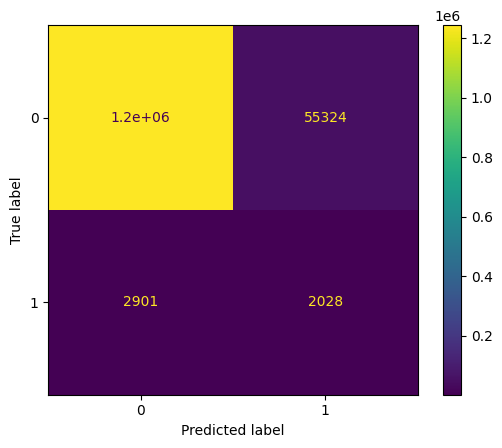

In [120]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [121]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,mcc_code,24.987989
1,operaton_amt,23.769117
2,event_desc,11.230213
3,pos_cd,7.192275
4,Hour,6.158107
5,channel_indicator_type,4.847042
6,event_type_nm,4.581655
7,device_system_version,3.686347
8,operating_system_type,2.789437
9,session_id,2.337404


In [122]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9462367449682427
Precision: 0.03197103230224714
Recall: 0.42961577329119094
F1-score: 0.059513225243901166
PR-AUC: 0.045854028785730805

Test metrics:
Accuracy: 0.9544494707097454
Precision: 0.03576233374772228
Recall: 0.426049908703591
F1-score: 0.06598586017282011
PR-AUC: 0.04605825493425612

Confusion matrix


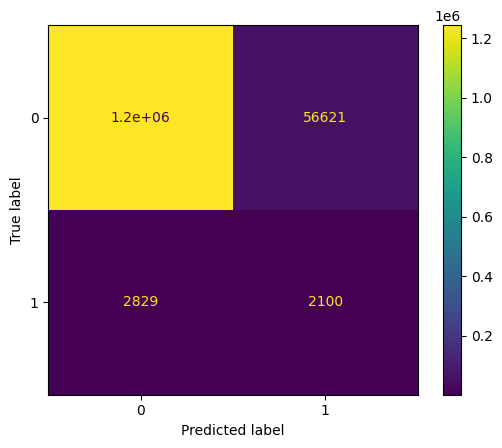

In [123]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [124]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,27.654875
1,mcc_code,16.704868
2,pos_cd,9.929421
3,event_desc,9.484418
4,event_type_nm,8.670181
5,Hour,6.457139
6,channel_indicator_type,6.013915
7,device_system_version,2.950810
8,phone_voip_call_state,2.464056
9,operating_system_type,2.094020


In [125]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9469308362280052
Precision: 0.032684546251395406
Recall: 0.4337440065363693
F1-score: 0.060788414251964705
PR-AUC: 0.04834915423081039

Test metrics:
Accuracy: 0.9549927057857217
Precision: 0.036534950218761846
Recall: 0.4303104077906269
F1-score: 0.06735150754965626
PR-AUC: 0.05034219531037841

Confusion matrix


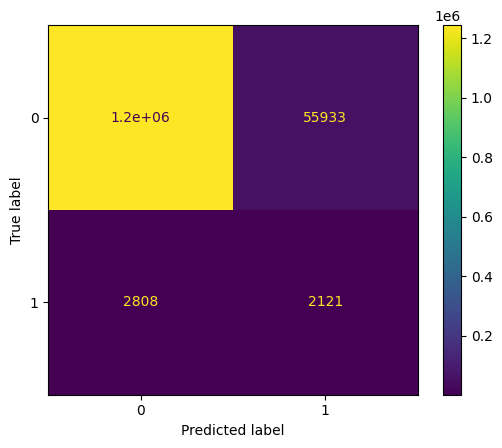

In [126]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [127]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,27.978662
1,mcc_code,16.026402
2,event_desc,11.150631
3,pos_cd,9.995012
4,event_type_nm,7.235590
5,Hour,6.412966
6,channel_indicator_type,4.426500
7,operating_system_type,3.130556
8,session_id,2.551119
9,device_system_version,2.427906
